In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import scipy.linalg as la
import skimage.io as io
import cv2

np.set_printoptions(floatmode="fixed", suppress=True, precision=2)

# Camera parameters calibration

## Load images

The pattern is $9 \times 6$ corners, with each square measuring $29 \times 29$ mm.

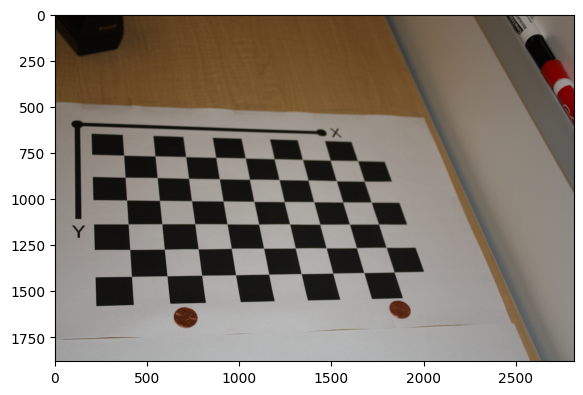

In [2]:
images = []
for i in range(1, 10):
    images.append(io.imread(f"img/image_calib_{i}.jpg"))

for img in images:
    plt.figure(figsize=(16/2, 9/2));
    plt.imshow(img)
    break

## Detect the patterns in all images

In [3]:
PATTERN = (9, 6)
SQ_SIZE = 0.029 # 29mm

# generate pattern as 3D points
objp = np.zeros((PATTERN[0]*PATTERN[1], 3), np.float32)
objp[:,:2] = SQ_SIZE * np.mgrid[0:PATTERN[0],0:PATTERN[1]].T.reshape(-1,2)

img_points = []
obj_points  = []
# criteria for corner detection refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, PATTERN, None)
    if ret: #successful detection
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria) # refine detections (optional)
        img_points.append(corners)
        obj_points.append(objp)

The image of an 3D point $X \in \mathbb{R}^3$ is given by $x = H_i X$, where for each image, $H_i$ is the projection matrix.

Every projection matrix can be decomposed into a $3 \times 3$ upper-triangular "intrinsic" matrix $K$ and a $3 \times 4$ "extrinsic" matrix $[R | t]$, corresponding to an rotation ($R$ is orthogonal) and a translation vector.

Since the camera is the same for all images, then there is a single $K$, but an $[R_i | t_i]$ for each image.

Given the correspondences, we solve an optimization problem to minimize the distance between the observed $x$ and the projections $H_i X$.

In [4]:
ret, K, dist, R, T = cv2.calibrateCamera(obj_points, img_points, gray.shape[::-1], None, None)
print("rmse: ", ret)

rmse:  0.9460627447798209


In [5]:
dist

array([[ -0.13,   3.56,   0.00,   0.00, -34.65]])

In [6]:
print("image center: ", np.r_[gray.T.shape] / 2)

image center:  [1408.00  940.00]


In [7]:
print(K)

[[4635.11    0.00 1462.78]
 [   0.00 4614.57  951.14]
 [   0.00    0.00    1.00]]


Lets check that the points are correctly projected:

[[4783.01 -586.94  634.23  750.30]
 [  46.79 2394.91 4057.24  750.92]
 [   0.13   -0.73    0.67    0.85]]


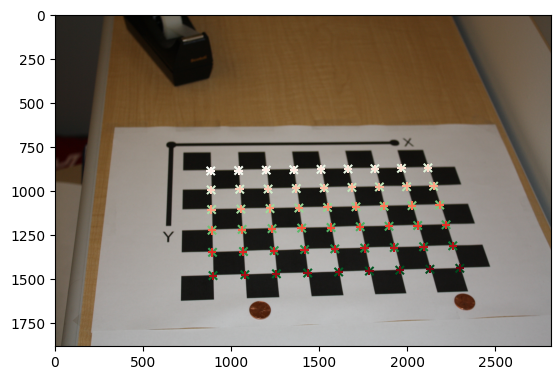

In [8]:
idx = 1
r = cv2.Rodrigues(R[idx])[0] # recover rotation matrix
t = T[idx] # recover translation vector

H = K @ np.c_[r, t]
print(H)

# project points
projected_points = H @ np.c_[objp, np.ones(objp.shape[0])].T
projected_points /= projected_points[-1]

plt.imshow(images[idx])

plt.scatter(img_points[idx][:, 0, 0], img_points[idx][:, 0, 1], marker="x", c=np.linspace(0, 1, 54), cmap=plt.colormaps['Greens']);
plt.scatter(projected_points[0], projected_points[1], marker="+", c=np.linspace(0, 1, 54), cmap=plt.colormaps['Reds']); 

# Removing optical distortion

## Understanding distortion types

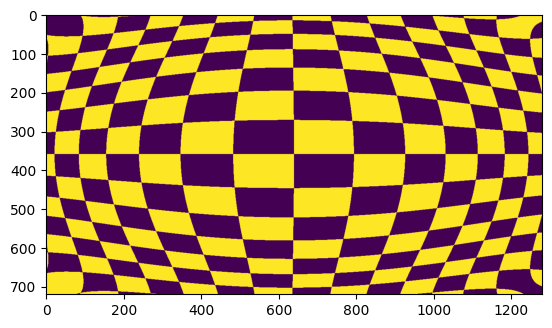

In [9]:
def print_pattern(x, y, fx, fy):
    zx = (fx * x) % 1 < 0.5
    zy = (fy * y) % 1 < 0.5
    return np.logical_xor(zx, zy)
    
x, y = np.meshgrid(np.linspace(-1, 1, 1280), np.linspace(-1, 1, 720))

def distort(x, y, k1=0, k2=0, p1=0, p2=0, k3=0):
    r = np.sqrt(x**2 + y**2)
    radial_factor = (1 + k1*r**2 + k2*r**4 + k3*r**6)
    tx = 2*p1*x*y + p2*(r**2 + 2*x**2)
    ty = 2*p2*x*y + p1*(r**2 + 2*y**2)

    return x*radial_factor + tx, y*radial_factor + ty

x_dist, y_dist = distort(x, y)

plt.imshow(print_pattern(*distort(x, y, k1=0.42, k2=0.45, p2=0.01, k3=-0.25), 2, 2));

## Load Images

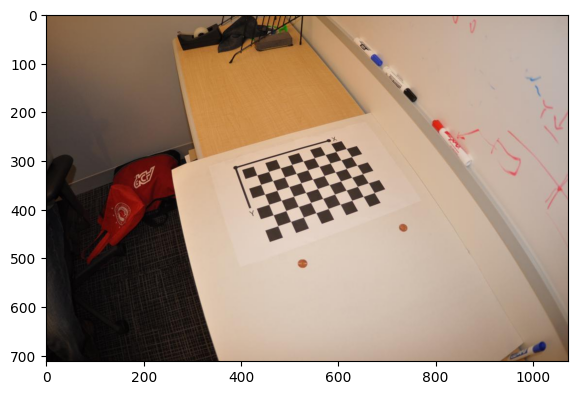

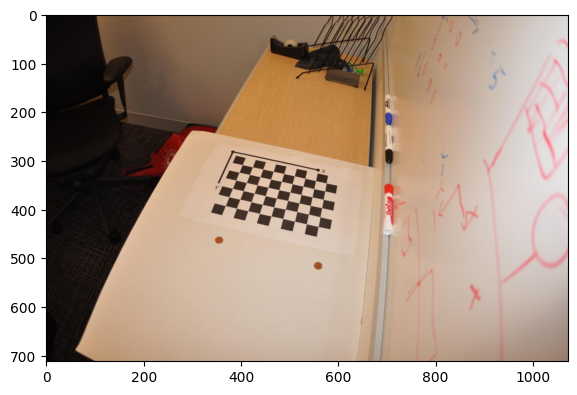

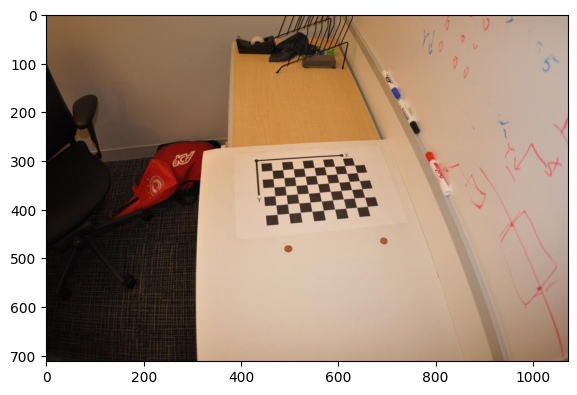

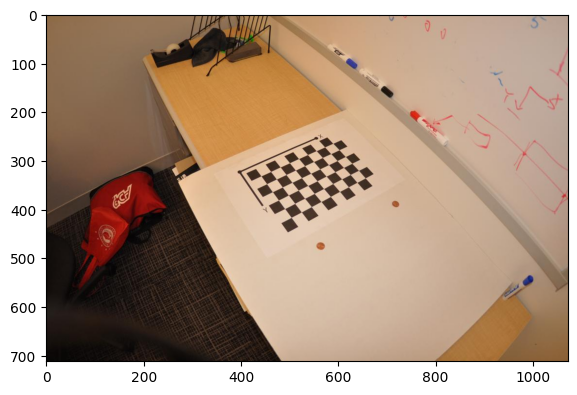

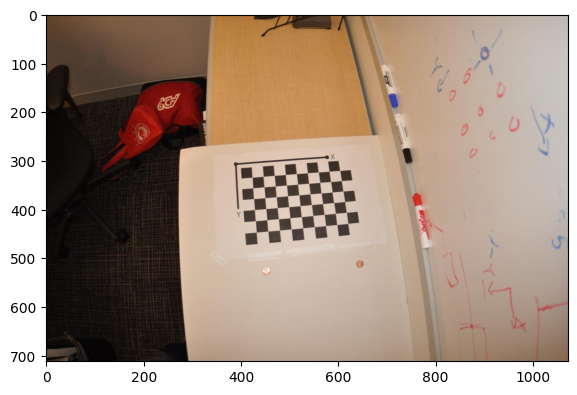

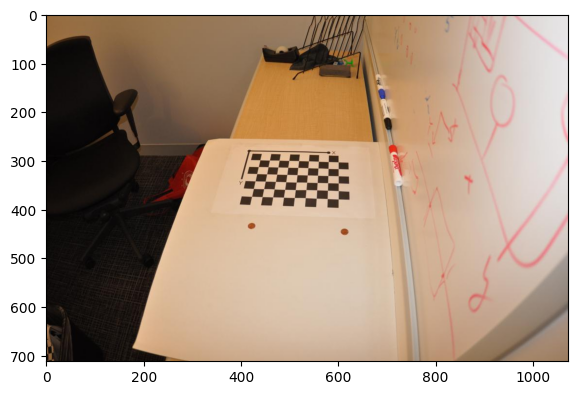

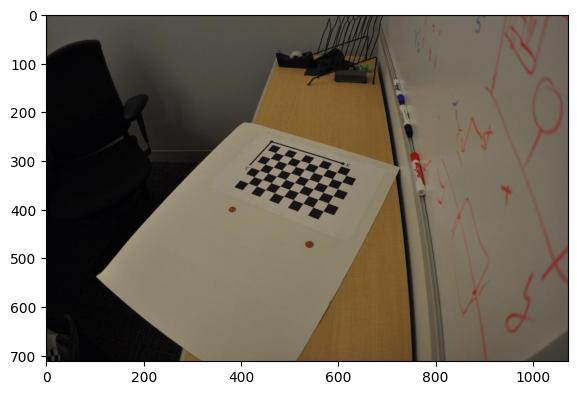

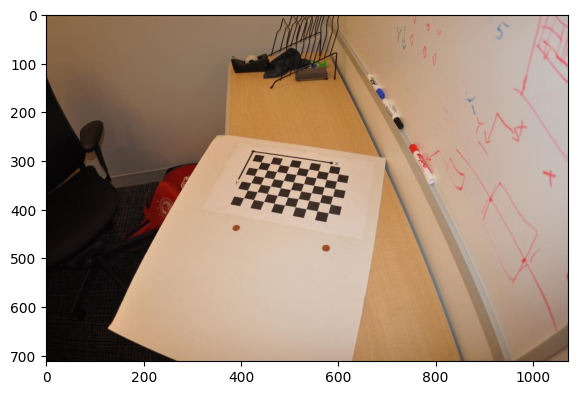

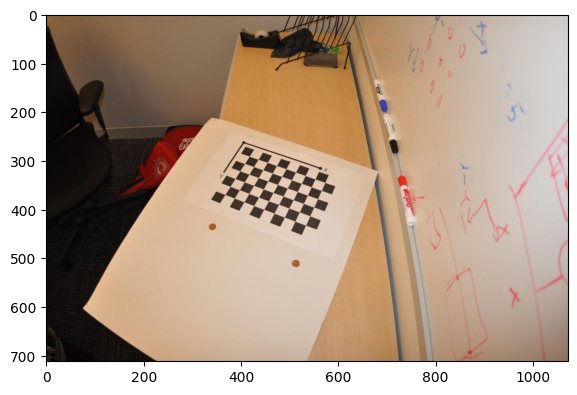

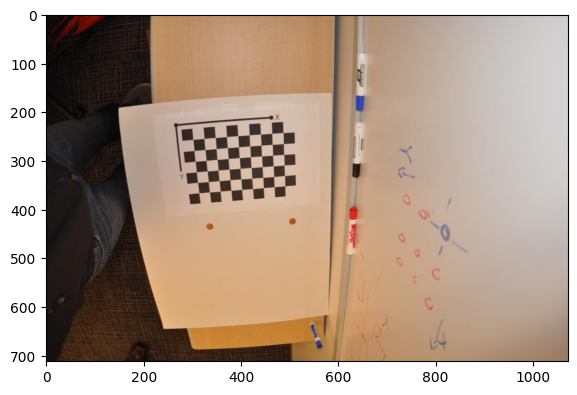

In [10]:
images = []
for i in range(1, 11):
    images.append(io.imread(f"img/image_dist_{i}.jpg"))

for img in images:
    plt.figure(figsize=(16/2, 9/2));
    plt.imshow(img)

In [11]:
PATTERN = (9, 6)
SQ_SIZE = 0.029 # 29mm

# generate pattern as 3D points
objp = np.zeros((PATTERN[0]*PATTERN[1], 3), np.float32)
objp[:,:2] = SQ_SIZE * np.mgrid[0:PATTERN[0],0:PATTERN[1]].T.reshape(-1,2)

img_points = []
obj_points  = []
# criteria for corner detection refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, PATTERN, None)
    if ret: #successful detection
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria) # refine detections (optional)
        img_points.append(corners)
        obj_points.append(objp)

In [12]:
ret, K, dist, R, T = cv2.calibrateCamera(obj_points, img_points, gray.shape[::-1], None, None)
print("rmse: ", ret)

rmse:  0.2338522093472266


In [13]:
dist

array([[-0.42,  0.45,  0.00, -0.01, -0.25]])

In [14]:
K

array([[733.48,   0.00, 575.61],
       [  0.00, 733.73, 346.83],
       [  0.00,   0.00,   1.00]])

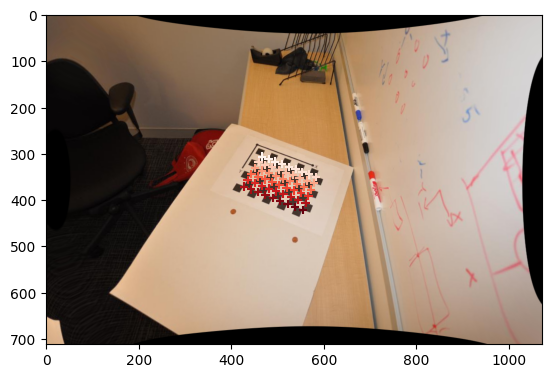

In [17]:
idx = 8
h, w = images[idx].shape[:2]
K_, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w,h), 1, (w,h))
dst = cv2.undistort(images[idx], K, dist, None, K_)
plt.imshow(dst)

# project points
H = K_ @ np.c_[cv2.Rodrigues(R[idx])[0], T[idx]]
projected_points = H @ np.c_[objp, np.ones(objp.shape[0])].T
projected_points /= projected_points[-1]
plt.scatter(projected_points[0], projected_points[1], marker="+", c=np.linspace(0, 1, 54), cmap=plt.colormaps['Reds']);

# uncomment to crop to detected clean roi
#plt.xlim(roi[0], roi[2])
#plt.ylim(roi[3], roi[1]);